# Lab 5 - Pandas
Author: Adam Jakubowski 193352

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from timeit import default_timer as timer

data = 'data/lab5Data10per.csv'

columns = ['Agency Name', 'Complaint Type', 'Borough', 'Location Type', 'Status']
start = timer()
df = pd.read_csv(data, usecols=columns)
end = timer()
print(f"Input data read in: {end - start:.4f} s")
df.head()

Input data read in: 12.1319 s


,Agency Name,Complaint Type,Location Type,Status,Borough
0,Department of Sanitation,Request Large Bulky Item Collection,Sidewalk,Closed,QUEENS
1,Department of Environmental Protection,Water System,NaN,Closed,BRONX
2,Department of Sanitation,Literature Request,Other,Open,BRONX
3,Department of Transportation,Traffic Signal Condition,NaN,Closed,QUEENS
4,Department of Sanitation,Sanitation Condition,Street,Closed,BROOKLYN


### Task 1: 10 most common complaint types (Complaint Type)

In [2]:
start = timer()
top_10_complaints = df['Complaint Type'].value_counts().head(10)
end = timer()
print(f"Task 1 executed in: {end - start:.4f} s")
print(top_10_complaints)

Task 1 executed in: 0.2871 s
Complaint Type
HEATING                   320518
GENERAL CONSTRUCTION      200602
Street Condition          182042
Street Light Condition    181450
Noise - Residential       180990
PLUMBING                  172803
PAINT - PLASTER           146160
Water System              113672
NONCONST                  108192
Literature Request         90880
Name: count, dtype: int64


### Task 2: Top 3 most common complaint types by borough (Borough)

In [3]:
start = timer()
boroughs = df['Borough'].unique()
print(f"Boroughs: {boroughs}")

for borough in boroughs:
    print(f"\nBorough: {borough}")
    borough_data = df[df['Borough'] == borough]
    top_3_complains_in_borough = borough_data['Complaint Type'].value_counts().head(3)
    print(top_3_complains_in_borough)

end = timer()
print(f"\nTask 2 executed in: {end - start:.4f} s")

Boroughs: <StringArray>
['QUEENS', 'BRONX', 'BROOKLYN', 'Unspecified', 'MANHATTAN', nan,
 'STATEN ISLAND']
Length: 7, dtype: str

Borough: QUEENS
Complaint Type
Street Light Condition    57890
Street Condition          50423
Noise - Residential       34522
Name: count, dtype: int64

Borough: BRONX
Complaint Type
Noise - Residential       48304
Street Light Condition    36789
Water System              23176
Name: count, dtype: int64

Borough: BROOKLYN
Complaint Type
Noise - Residential       54048
Street Condition          50829
Street Light Condition    48975
Name: count, dtype: int64

Borough: Unspecified
Complaint Type
HEATING                 282707
GENERAL CONSTRUCTION    150258
PLUMBING                132293
Name: count, dtype: int64

Borough: MANHATTAN
Complaint Type
Noise - Residential    39259
Street Condition       37277
Taxi Complaint         23677
Name: count, dtype: int64

Borough: nan
Series([], Name: count, dtype: int64)

Borough: STATEN ISLAND
Complaint Type
Street Condit

### Task 3: Top 3 most common agencies for which most complaints were made

In [5]:
start = timer()
top_3_agencies = df['Agency Name'].value_counts().head(3).index

for agency in top_3_agencies:
    print(f"\nAgency: {agency}")
    agency_data = df[df['Agency Name'] == agency]
    top_3_complaints = agency_data['Complaint Type'].value_counts().head(3)
    print(top_3_complaints)

end = timer()
print(f"\nTask 3 executed in: {end - start:.4f} s")


Agency: Department of Housing Preservation and Development
Complaint Type
HEATING                 320518
GENERAL CONSTRUCTION    200602
PLUMBING                172803
Name: count, dtype: int64

Agency: Department of Transportation
Complaint Type
Street Condition            182041
Street Light Condition      181450
Traffic Signal Condition     85210
Name: count, dtype: int64

Agency: New York City Police Department
Complaint Type
Noise - Residential    180941
Blocked Driveway        81871
Illegal Parking         41803
Name: count, dtype: int64

Task 3 executed in: 1.0110 s


### Task 4: Top 4 locations where most complaints were made (Location Type)

In [6]:
start = timer()
top_4_locations = df['Location Type'].value_counts().head(4).index

for location in top_4_locations:
    print(f"\nLocation: {location}")
    location_data = df[df['Location Type'] == location]
    top_2_complaints = location_data['Complaint Type'].value_counts().head(2)
    print(top_2_complaints)

end = timer()
print(f"\nTask 4 executed in: {end - start:.4f} s")


Location: RESIDENTIAL BUILDING
Complaint Type
HEATING                 320518
GENERAL CONSTRUCTION    200602
Name: count, dtype: int64

Location: Street
Complaint Type
Street Condition    75598
Damaged Tree        47538
Name: count, dtype: int64

Location: Street/Sidewalk
Complaint Type
Blocked Driveway    81871
Illegal Parking     41802
Name: count, dtype: int64

Location: Residential Building/House
Complaint Type
Noise - Residential            180990
Non-Emergency Police Matter      2249
Name: count, dtype: int64

Task 4 executed in: 1.0444 s


### Task 5: Percentage of different statuses of complaints (Status)

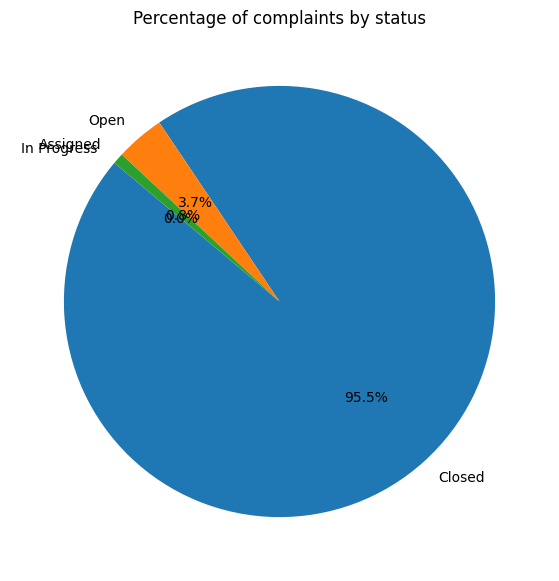

Task 5 executed in: 0.7248 s


In [13]:
start = timer()
statuses = ['In Progress', 'Closed', 'Open', 'Assigned']
status_counts = df[df['Status'].isin(statuses)]['Status'].value_counts()

plt.figure(figsize=(10, 7))
status_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Percentage of complaints by status')
plt.ylabel('')
plt.show()

end = timer()
print(f"Task 5 executed in: {end - start:.4f} s")